In [2]:
import pandas as pd
print("Setup complete")

Setup complete


In [3]:
import os

# usage of ../data avoids the backslash error entirely
files = os.listdir('../data')
print(files)

['data.csv']


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# This works now because we fixed the folder structure!
df = pd.read_csv('../data/data.csv')

# Success check
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Convert TotalCharges to numeric
# errors='coerce' means: "If you find text, turn it into NaN (Not a Number)"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if it worked
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# Convert TotalCharges to numeric
# errors='coerce' means: "If you find text, turn it into NaN (Not a Number)"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if it worked
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

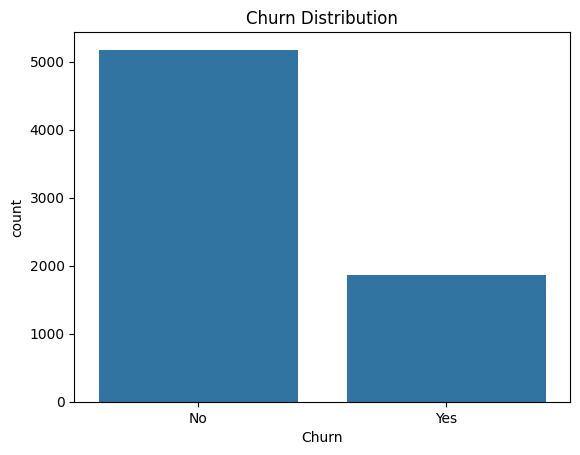

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [8]:
# Check the target balance
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Print the exact percentage
print(df['Churn'].value_counts(normalize=True))

In [9]:
# Check for missing values before cleaning
print("Missing before:", df.isnull().sum().sum())

# Drop rows with missing values
df.dropna(inplace=True)

# Remove the 'customerID' column (it is useless for prediction)
# If we don't drop it, the model will think the ID number predicts churn!
df.drop(columns=['customerID'], inplace=True)

# Confirm clean
print("Missing after:", df.isnull().sum().sum())                                                                    

Missing before: 11
Missing after: 0


In [10]:
from sklearn.model_selection import train_test_split

# 1. Prepare X (Features) and y (Target)
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0}) # Convert Yes/No to 1/0

# 2. Split into Train (80%) and Test (20%)
# random_state=42 ensures we get the same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes:  {X_test.shape}, {y_test.shape}")

Training shapes: (5625, 19), (5625,)
Testing shapes:  (1407, 19), (1407,)


In [11]:
# Convert categorical variables (Text) into numbers
# This turns "Gender" column into "Gender_Male" (0 or 1) and "Gender_Female" (0 or 1)
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# ALIGNMENT STEP (Critical!)
# Sometimes the train set has a category that the test set doesn't (or vice versa).
# This code ensures both have the exact same columns, filling missing ones with 0.
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print("Encoding complete.")

Encoding complete.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
model = LogisticRegression(max_iter=1000)

# 2. Train (Fit) the model on the Study Guide
print("Training the model...")
model.fit(X_train_encoded, y_train)

# 3. Take the Exam (Predict)
print("Predicting...")
y_pred = model.predict(X_test_encoded)

print("Done.")

Training the model...
Predicting...
Done.


c:\Users\yashd\churn-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[916 117]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [14]:
# IMPROVEMENT 1: Logistic Regression with Class Weighting
# class_weight='balanced' automatically adjusts for the fact that we have fewer churners
model_balanced = LogisticRegression(max_iter=2000, class_weight='balanced')

print("Training Balanced Model...")
model_balanced.fit(X_train_encoded, y_train)

# Predict
y_pred_balanced = model_balanced.predict(X_test_encoded)

# Evaluate
print("Balanced Logistic Regression Report:")
print(classification_report(y_test, y_pred_balanced))

Training Balanced Model...
Balanced Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



c:\Users\yashd\churn-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.ensemble import RandomForestClassifier

# IMPROVEMENT 2: Random Forest
# n_estimators=100 means "Build 100 decision trees"
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("Training Random Forest...")
rf_model.fit(X_train_encoded, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_encoded)

# Evaluate
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

Training Random Forest...
Random Forest Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.44      0.52       374

    accuracy                           0.78      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [16]:
# Get the probability scores (0.0 to 1.0)
y_prob = model_balanced.predict_proba(X_test_encoded)[:, 1]

# If the probability is > 0.4, call it "Churn" (Riskier!)
y_pred_tuned = (y_prob >= 0.4).astype(int)

print("Tuned Threshold (0.4) Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Threshold (0.4) Report:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74      1033
           1       0.45      0.86      0.59       374

    accuracy                           0.68      1407
   macro avg       0.69      0.74      0.66      1407
weighted avg       0.80      0.68      0.70      1407



In [17]:
import joblib

# We are saving TWO things together in a dictionary:
# 1. The Model itself
# 2. The list of columns (So we can recreate them perfectly in the API)
model_data = {
    'model': model_balanced,
    'features': X_train_encoded.columns.tolist()
}

# Save it to the models folder
joblib.dump(model_data, '../models/churn_model.pkl')

print("Model saved to ../models/churn_model.pkl")

Model saved to ../models/churn_model.pkl
